In [ ]:
import requests
from dotenv import load_dotenv
from os import getenv
import pandas as pd
# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
load_dotenv()
API_KEY = getenv('ALPHA_VANTAGE_API')
url = f'https://www.alphavantage.co/query?function=REAL_GDP&interval=annual&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

df = pd.DataFrame(data)
df

<BarContainer object of 11 artists>

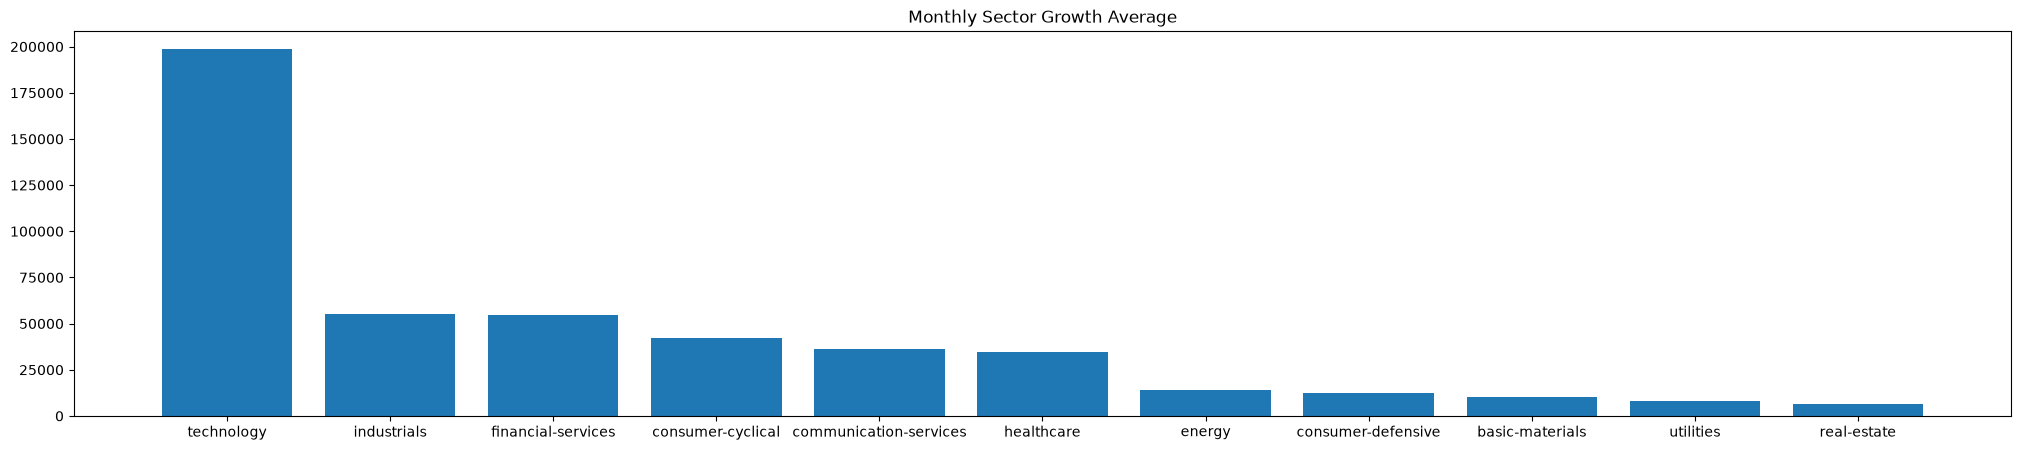

In [1]:
import yfinance as yf, pandas as pd, matplotlib.pyplot as plt
sectors = ['basic-materials', 'communication-services', 'consumer-cyclical',
            'consumer-defensive', 'energy', 'financial-services', 'healthcare', 'industrials', 
            'real-estate', 'technology', 'utilities']

def get_earning_month(sector:str):
  sect = yf.Sector(sector)
  # test = pd.DataFrame(tech.ticker.get_capital_gains(period='max'))
  # test
  df = sect.ticker.history(period = 'max')
  df = df.sort_index()
  df.index = df.index.strftime('%Y-%m')
  rsl = df.groupby('Date')['Close'].agg(
    growth = lambda x: x.iloc[-1] - x.iloc[0]
  )
  return rsl.mean()

data = { sector: get_earning_month(sector) for sector in sectors}
df = pd.DataFrame(data).T
df.sort_values('growth', ascending=False, inplace= True)
plt.figure(figsize = (25, 5))
plt.title("Monthly Sector Growth Average")
plt.bar(x = df.index, height = df.growth)

In [9]:
best_sectors = ['technology', 'financial-services', 'industrials', 'consumer-cyclical', 'communication-services']
# for sector in best_sectors:
#   sect = yf.Sector(sector)

yf.Sector('technology').top_companies.shape

(50, 3)

418